### Problem Statement

You are a data scientist / AI engineer working on a breast cancer recurrence prediction project. You have been provided with a dataset named **`"breast_cancer_data.csv"`**, which includes various clinical and pathological factors influencing the recurrence of breast cancer. The dataset comprises the following columns:

- `age:` Age of the patient (ranges: 30-39, 40-49, 50-59, 60-69).
- `menopause:` Menopause status of the patient (premeno, ge40, lt40).
- `tumor-size:` Size of the tumor (ranges in mm).
- `inv-nodes:` Number of involved lymph nodes (ranges).
- `node-caps:` Whether node caps are present (yes or no).
- `deg-malig:` Degree of malignancy (1, 2, 3).
- `breast:` Breast involved (left or right).
- `breast-quad:` Quadrant of the breast involved (left_up, left_low, right_up, right_low, central).
- `irradiat:` Whether the patient received irradiation (yes or no).
- `class:` Recurrence of breast cancer (no-recurrence-events, recurrence-events).

Your task is to analyze this dataset to understand the factors contributing to breast cancer recurrence. You will handle class imbalance using various techniques and build machine learning models to predict whether a patient will experience recurrence events based on the provided features.

In [14]:
# # Dataset Credits

# Zwitter,Matjaz and Soklic,Milan. (1988). Breast Cancer. 
# UCI Machine Learning Repository. https://doi.org/10.24432/C51P4M.

**Import Necessary Libraries**

In [28]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

### Task 1: Data Preparation and Exploration

1. Import the dataset and display the first few rows to understand its structure.
2. Check for any missing values in the dataset and handle them appropriately.
3. Visualize the class distribution to identify any class imbalance in the dataset.
4. Encoding categorical variables using one-hot encoding for the following columns: `age, menopause, tumor-size, inv-nodes, node-caps, breast, breast-quad, irradiat`.

In [2]:
# Step 1: Import the dataset and display the first few rows
df = pd.read_csv("breast_cancer_data.csv")
df.head()

,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat,class
0,30-39,premeno,30-34,0-2,no,3,left,left_low,no,no-recurrence-events
1,40-49,premeno,20-24,0-2,no,2,right,right_up,no,no-recurrence-events
2,40-49,premeno,20-24,0-2,no,2,left,left_low,no,no-recurrence-events
3,60-69,ge40,15-19,0-2,no,2,right,left_up,no,no-recurrence-events
4,40-49,premeno,0-4,0-2,no,2,right,right_low,no,no-recurrence-events


In [3]:
# Step 2: Check for any missing values in the dataset and handle them appropriately
df.isna().sum()


age            0
menopause      0
tumor-size     0
inv-nodes      0
node-caps      8
deg-malig      0
breast         0
breast-quad    0
irradiat       0
class          0
dtype: int64

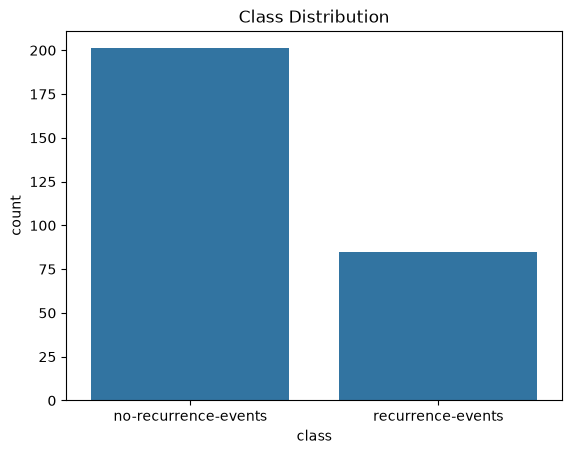

In [4]:
# Step 3: Visualize the class distribution to identify any class imbalance in the dataset
sns.countplot(x='class', data=df)
plt.title('Class Distribution')
plt.show()

In [6]:
# Step 4: Encoding categorical variables using one-hot encoding for the following columns:
# age, menopause, tumor-size, inv-nodes, node-caps, breast, breast-quad, irradiat.
df = pd.get_dummies(df, columns=["age", "menopause", "tumor-size", "inv-nodes", "node-caps", "breast", "breast-quad", "irradiat"], drop_first=True)
df.head()


,deg-malig,class,age_30-39,age_40-49,age_50-59,age_60-69,age_70-79,menopause_lt40,menopause_premeno,tumor-size_09-May,...,inv-nodes_14-Dec,inv-nodes_15-17,inv-nodes_24-26,node-caps_yes,breast_right,breast-quad_left_low,breast-quad_left_up,breast-quad_right_low,breast-quad_right_up,irradiat_yes
0,3,no-recurrence-events,True,False,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,2,no-recurrence-events,False,True,False,False,False,False,True,False,...,False,False,False,False,True,False,False,False,True,False
2,2,no-recurrence-events,False,True,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
3,2,no-recurrence-events,False,False,False,True,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False
4,2,no-recurrence-events,False,True,False,False,False,False,True,False,...,False,False,False,False,True,False,False,True,False,False


### Task 2: Logistic Regression Model Without Handling Class Imbalance

1. Split the dataset into training and test sets.
2. Train a Logistic Regression model using the training data.
3. Evaluate the model using a classification report, including precision, recall, and F1-score.

In [9]:
# Step 1: Split the dataset into training and test sets
X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Step 2: Train a Logistic Regression model using the training data
model = LogisticRegression()
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [12]:
# Step 3: Evaluate the model using a classification report, including precision, recall, and F1-score
y_test_pred = model.predict(X_test)
print(y_test_pred[:10])
print(y_test[:10].tolist())

report = classification_report(y_test, y_test_pred)
print(report)

['no-recurrence-events' 'recurrence-events' 'no-recurrence-events'
 'no-recurrence-events' 'no-recurrence-events' 'no-recurrence-events'
 'no-recurrence-events' 'no-recurrence-events' 'no-recurrence-events'
 'no-recurrence-events']
['no-recurrence-events', 'recurrence-events', 'no-recurrence-events', 'recurrence-events', 'recurrence-events', 'no-recurrence-events', 'recurrence-events', 'no-recurrence-events', 'no-recurrence-events', 'no-recurrence-events']
                      precision    recall  f1-score   support

no-recurrence-events       0.67      0.92      0.77        37
   recurrence-events       0.57      0.19      0.29        21

            accuracy                           0.66        58
           macro avg       0.62      0.55      0.53        58
        weighted avg       0.63      0.66      0.60        58



### Task 3: Handling Class Imbalance Using Undersampling

1. Apply undersampling to balance the classes in the training data.
2. Train a Logistic Regression model using the undersampled training data.
3. Evaluate the model using a classification report, including precision, recall, and F1-score.

In [29]:
# Step 1: Apply undersampling to balance the classes in the training data
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
print(y_train_rus.value_counts())

class
no-recurrence-events    64
recurrence-events       64
Name: count, dtype: int64


In [22]:
# Step 2: Train a Logistic Regression model using the undersampled training data
model = LogisticRegression(max_iter=2000)
model.fit(X_train_rus, y_train_rus)

y_pred_rus = model.predict(X_test)

In [25]:
# Step 3: Evaluate the model using a classification report, including precision, recall, and F1-score
print("Classification report for RUS: \n")
report = classification_report(y_test, y_pred_rus)
print(report)

Classification report for RUS: 

                      precision    recall  f1-score   support

no-recurrence-events       0.73      0.73      0.73        37
   recurrence-events       0.52      0.52      0.52        21

            accuracy                           0.66        58
           macro avg       0.63      0.63      0.63        58
        weighted avg       0.66      0.66      0.66        58



### Task 4: Handling Class Imbalance Using SMOTE (Oversampling)

1. Apply SMOTE (Synthetic Minority Over-sampling Technique) to balance the classes in the training data.
2. Train a Logistic Regression model using the SMOTE-balanced training data.
3. Evaluate the model using a classification report, including precision, recall, and F1-score.

In [31]:
# Step 1: Apply SMOTE to balance the classes in the training data
smt = SMOTE(random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train, y_train)
print(y_train_smt.value_counts())

# Step 2: Train a Logistic Regression model using the SMOTE-balanced training data
model = LogisticRegression(max_iter=2000)
model.fit(X_train_smt, y_train_smt)

y_pred_smt = model.predict(X_test)

# Step 3: Evaluate the model using a classification report, including precision, recall, and F1-score
print("Classification Report for SMT: \n", classification_report(y_test, y_pred_smt))

class
no-recurrence-events    164
recurrence-events       164
Name: count, dtype: int64
Classification Report for SMT: 
                       precision    recall  f1-score   support

no-recurrence-events       0.73      0.81      0.77        37
   recurrence-events       0.59      0.48      0.53        21

            accuracy                           0.69        58
           macro avg       0.66      0.64      0.65        58
        weighted avg       0.68      0.69      0.68        58



### Task 5: Handling Class Imbalance Using SMOTE Tomek Links

1. Apply SMOTE Tomek Links to balance the classes in the training data.
2. Train a Logistic Regression model using the SMOTE Tomek Links-balanced training data.
3. Evaluate the model using a classification report, including precision, recall, and F1-score.

In [33]:
# Step 1: Apply SMOTE Tomek Links to balance the classes in the training data
smt_tomek = SMOTETomek(random_state=42)
X_train_smtek, y_train_smtek = smt_tomek.fit_resample(X_train, y_train)
print(y_train_smtek.value_counts())

# Step 2: Train a Logistic Regression model using the SMOTE Tomek Links-balanced training data
model = LogisticRegression(max_iter=2000)
model.fit(X_train_smtek, y_train_smtek)

y_pred_smtek = model.predict(X_test)

# Step 3: Evaluate the model using a classification report, including precision, recall, and F1-score
print("Classification Report for SMT: \n", classification_report(y_test, y_pred_smtek))

class
no-recurrence-events    155
recurrence-events       155
Name: count, dtype: int64
Classification Report for SMT: 
                       precision    recall  f1-score   support

no-recurrence-events       0.72      0.78      0.75        37
   recurrence-events       0.56      0.48      0.51        21

            accuracy                           0.67        58
           macro avg       0.64      0.63      0.63        58
        weighted avg       0.66      0.67      0.67        58

